## 1. Import Libraries và Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
from scipy.stats import shapiro, skew, kurtosis

warnings.filterwarnings('ignore')

# Thiết lập style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [ ]:
# Load dataset
df = pd.read_csv('Dry_Eye_Dataset.csv')
print(f"Số lượng mẫu: {len(df)}")
print(f"Số cột: {len(df.columns)}")
df.head()

Số lượng mẫu: 20000
Số cột: 26


,Gender,Age,Sleep duration,Sleep quality,Stress level,Blood pressure,Heart rate,Daily steps,Physical activity,Height,Weight,Sleep disorder,Wake up during night,Feel sleepy during day,Caffeine consumption,Alcohol consumption,Smoking,Medical issue,Ongoing medication,Smart device before bed,Average screen time,Blue-light filter,Discomfort Eye-strain,Redness in eye,Itchiness/Irritation in eye,Dry Eye Disease
0,F,24,9.50,2,1,137/89,67,3000,31,161,69,Y,N,N,N,N,N,Y,Y,N,8.70,N,Y,Y,N,Y
1,M,39,9.60,2,3,108/64,60,12000,74,164,87,N,N,N,N,Y,N,Y,Y,N,9.60,Y,N,N,Y,Y
2,F,45,5.40,1,5,134/81,95,12000,93,179,94,Y,Y,N,Y,Y,N,N,N,Y,4.00,N,Y,N,N,N
3,F,45,5.40,4,5,110/90,78,19000,32,160,77,N,N,N,Y,N,N,Y,N,N,7.60,N,Y,N,Y,N
4,F,42,5.70,3,2,99/67,72,4000,173,179,99,N,Y,N,N,N,N,Y,N,N,3.50,N,Y,Y,N,Y


## 2. Khám Phá Dữ Liệu Cơ Bản

In [ ]:
# Thông tin tổng quan
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Gender                       20000 non-null  object 
 1   Age                          20000 non-null  int64  
 2   Sleep duration               20000 non-null  float64
 3   Sleep quality                20000 non-null  int64  
 4   Stress level                 20000 non-null  int64  
 5   Blood pressure               20000 non-null  object 
 6   Heart rate                   20000 non-null  int64  
 7   Daily steps                  20000 non-null  int64  
 8   Physical activity            20000 non-null  int64  
 9   Height                       20000 non-null  int64  
 10  Weight                       20000 non-null  int64  
 11  Sleep disorder               20000 non-null  object 
 12  Wake up during night         20000 non-null  object 
 13  Feel sleepy duri

In [ ]:
# Kiểm tra missing values
print("Missing values:")
print(df.isnull().sum())

Missing values:
Gender                         0
Age                            0
Sleep duration                 0
Sleep quality                  0
Stress level                   0
Blood pressure                 0
Heart rate                     0
Daily steps                    0
Physical activity              0
Height                         0
Weight                         0
Sleep disorder                 0
Wake up during night           0
Feel sleepy during day         0
Caffeine consumption           0
Alcohol consumption            0
Smoking                        0
Medical issue                  0
Ongoing medication             0
Smart device before bed        0
Average screen time            0
Blue-light filter              0
Discomfort Eye-strain          0
Redness in eye                 0
Itchiness/Irritation in eye    0
Dry Eye Disease                0
dtype: int64


In [ ]:
# Thống kê mô tả cho các biến quan trọng
cols_of_interest = ['Average screen time', 'Caffeine consumption', 'Alcohol consumption', 'Smoking', 'Dry Eye Disease']
df[cols_of_interest].describe()

,Average screen time
count,20000.00
mean,5.52
std,2.61
min,1.00
25%,3.30
50%,5.50
75%,7.80
max,10.00



Tỷ lệ mắc Dry Eye Disease:
Dry Eye Disease
Y   65.19
N   34.82
Name: proportion, dtype: float64


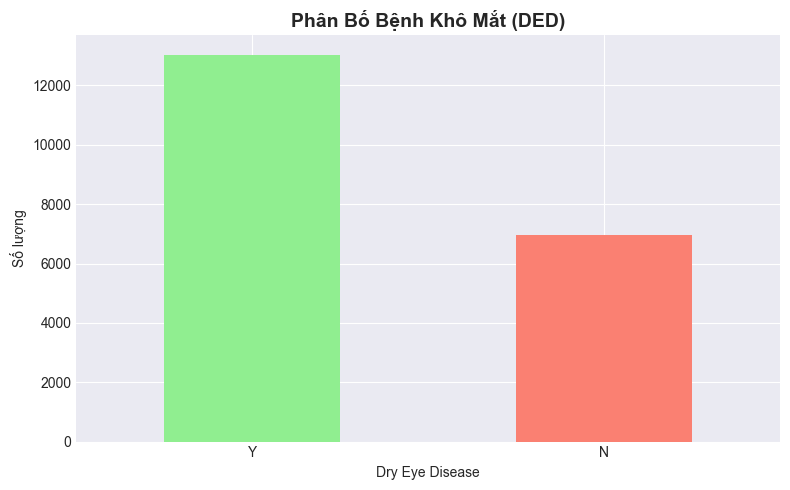

In [ ]:
# Tỷ lệ mắc DED trong dataset
ded_rate = df['Dry Eye Disease'].value_counts(normalize=True) * 100
print("\nTỷ lệ mắc Dry Eye Disease:")
print(ded_rate)

# Visualization
plt.figure(figsize=(8, 5))
df['Dry Eye Disease'].value_counts().plot(kind='bar', color=['lightgreen', 'salmon'])
plt.title('Phân Bố Bệnh Khô Mắt (DED)', fontsize=14, fontweight='bold')
plt.xlabel('Dry Eye Disease')
plt.ylabel('Số lượng')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Screen Time và Tỷ Lệ DED

### 3.1. Phân Tích Tổng Quan Screen Time

In [ ]:
# Thống kê mô tả Screen Time
print("Thống kê Average Screen Time:")
print(df['Average screen time'].describe())
print(f"\nMedian: {df['Average screen time'].median():.2f} giờ")

# Kiểm tra phân phối Screen Time

print(f"\nSkewness: {skew(df['Average screen time']):.4f}")
print(f"Kurtosis: {kurtosis(df['Average screen time']):.4f}")

stat, p = shapiro(df['Average screen time'])
print(f"\nShapiro-Wilk Test: stat={stat:.4f}, p-value={p:.4f}")
if p > 0.05:
    print("Dữ liệu phân phối chuẩn (không bác bỏ H0)")
else:
    print("Dữ liệu không phân phối chuẩn (bác bỏ H0)")

Thống kê Average Screen Time:
count   20000.00
mean        5.52
std         2.61
min         1.00
25%         3.30
50%         5.50
75%         7.80
max        10.00
Name: Average screen time, dtype: float64

Median: 5.50 giờ

Skewness: -0.0088
Kurtosis: -1.2034

Shapiro-Wilk Test: stat=0.9545, p-value=0.0000
Dữ liệu không phân phối chuẩn (bác bỏ H0)


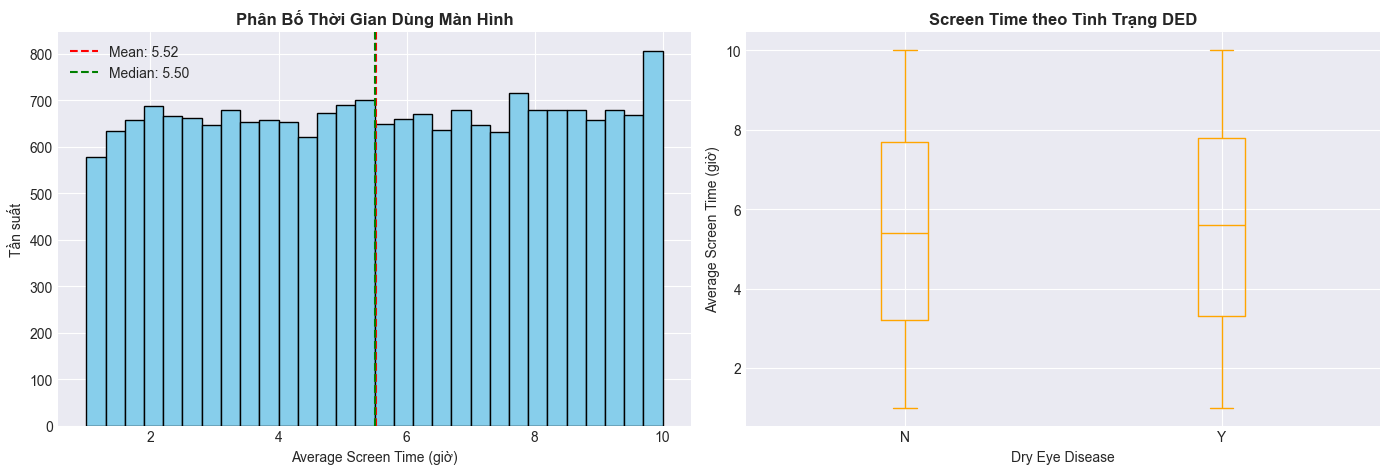

In [ ]:
# Phân bố Screen Time
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['Average screen time'], bins=30, color='skyblue', edgecolor='black')
axes[0].axvline(df['Average screen time'].mean(), color='red', linestyle='--', label=f'Mean: {df["Average screen time"].mean():.2f}')
axes[0].axvline(df['Average screen time'].median(), color='green', linestyle='--', label=f'Median: {df["Average screen time"].median():.2f}')
axes[0].set_xlabel('Average Screen Time (giờ)')
axes[0].set_ylabel('Tần suất')
axes[0].set_title('Phân Bố Thời Gian Dùng Màn Hình', fontweight='bold')
axes[0].legend()

# Boxplot by DED
df.boxplot(column='Average screen time', by='Dry Eye Disease', ax=axes[1], color='orange')
axes[1].set_xlabel('Dry Eye Disease')
axes[1].set_ylabel('Average Screen Time (giờ)')
axes[1].set_title('Screen Time theo Tình Trạng DED', fontweight='bold')
plt.suptitle('')

plt.tight_layout()
plt.show()

**Nhận xét sơ bộ về thời gian sử dụng thiết bị điện tử**

**1. Phân bố thời gian dùng màn hình**
- Thời gian sử dụng thiết bị điện tử (Average Screen Time) dao động từ **1 đến 10 giờ mỗi ngày**.
- Mean = **5.52 giờ**, Median = **5.50 giờ**, cho thấy phân bố **gần đối xứng**.
- Khoảng 50% người dùng dành **3.3–7.8 giờ/ngày** cho màn hình — một mức độ khá cao, dễ gây mỏi mắt hoặc khô mắt.
- Histogram cho thấy phân bố tương đối **đều**, chứng tỏ thói quen dùng thiết bị không bị lệch về nhóm nào cụ thể.

**2. So sánh Screen Time theo tình trạng Dry Eye Disease**
- Boxplot cho thấy nhóm **DED = Y** và **DED = N** có median gần như bằng nhau.
- Nhóm mắc DED có mức dao động screen time **rộng hơn một chút**, nhưng chưa thấy sự khác biệt rõ rệt.
- Điều này cho thấy **dữ liệu ban đầu không bộc lộ sự khác biệt lớn** về Screen Time giữa 2 nhóm.

---

**Hướng phân tích tiếp theo**
Để xác định xem **screen time có ảnh hưởng đến DED hay không**, cần thực hiện các kiểm định thống kê


### 3.2. So Sánh Screen Time giữa Nhóm DED và Không DED

In [ ]:
# So sánh trung bình Screen Time
screen_time_ded = df.groupby('Dry Eye Disease')['Average screen time'].agg(['mean', 'median', 'std', 'count'])
print("\nSo sánh Screen Time theo DED:")
print(screen_time_ded)


So sánh Screen Time theo DED:
                 mean  median  std  count
Dry Eye Disease                          
N                5.44    5.40 2.58   6963
Y                5.56    5.60 2.62  13037


In [ ]:
# T-test: So sánh Screen Time giữa 2 nhóm
ded_yes = df[df['Dry Eye Disease'] == 'Y']['Average screen time']
ded_no = df[df['Dry Eye Disease'] == 'N']['Average screen time']

U, p_value = mannwhitneyu(ded_no, ded_yes, alternative="two-sided")

print("Mann–Whitney U Test:")
print("U statistic =", U)
print("p-value =", p_value)

n1 = len(ded_no)
n2 = len(ded_yes)

# Rank-Biserial Correlation
rbc = 1 - (2 * U) / (n1 * n2)

print("Effect size (Rank-Biserial Correlation) =", rbc)

Mann–Whitney U Test:
U statistic = 44148751.0
p-value = 0.001437878048151166
Effect size (Rank-Biserial Correlation) = 0.027310211589588462


**Nhận xét: Ảnh hưởng của Screen Time đến Dry Eye Disease (DED)**

**1. So sánh mô tả (Descriptive Statistics)**
- Nhóm **không mắc DED (N)** có thời gian dùng màn hình trung bình **5.44 giờ**.
- Nhóm **mắc DED (Y)** có thời gian trung bình **5.56 giờ**, cao hơn một chút (~0.12 giờ).
- Median của hai nhóm:
  - N: **5.40 giờ**
  - Y: **5.60 giờ**
- Độ lệch chuẩn gần như tương đương (≈ 2.6 giờ).

→ **Sự khác biệt về mặt mô tả là rất nhỏ**, gần như không đáng kể về mặt thực tế.

---

**2. Kiểm định Mann–Whitney U**
- **p = 0.0014 < 0.05**  
→ Có **khác biệt có ý nghĩa thống kê** giữa thời gian dùng màn hình của hai nhóm DED và không DED.

Tuy nhiên, “có ý nghĩa thống kê” không đồng nghĩa với “ảnh hưởng mạnh”.

---

**3. Effect size (Rank-Biserial Correlation)**
- **r = 0.0273**, thuộc mức:
  - |r| < 0.10 → **rất yếu**

→ Nghĩa là **mức độ ảnh hưởng của Screen Time lên DED hầu như bằng 0**.

---
**Kết luận chung**
- Dù kiểm định Mann–Whitney U cho thấy sự khác biệt giữa hai nhóm DED và không DED là *có ý nghĩa thống kê*, nhưng:
  - mức chênh lệch trung bình chỉ ~0.12 giờ,
  - effect size rất nhỏ (r ≈ 0.03),
  - phân phối hai nhóm gần như trùng nhau.

→ **Thời gian sử dụng thiết bị không phải là yếu tố quan trọng trong việc dự đoán hoặc giải thích khả năng mắc Dry Eye Disease.**

Nói cách khác:  
**Screen Time có sự khác biệt nhỏ nhưng không đủ mạnh để xem như một yếu tố nguy cơ đáng kể cho DED trong dataset này.**


### 3.3. Phân Tích Ngưỡng Screen Time (> 8 giờ/ngày)

In [ ]:
# Tạo nhóm theo ngưỡng Screen Time
df['Screen_Time_Category'] = pd.cut(df['Average screen time'],
                                      bins=[0, 4, 8, 12, float('inf')],
                                      labels=['<4h', '4-8h', '8-12h', '>12h'])

# Tỷ lệ DED theo từng nhóm
screen_time_ded_rate = df.groupby('Screen_Time_Category')['Dry Eye Disease'].apply(lambda x: (x == 'Y').sum() / len(x) * 100)
print("\nTỷ lệ DED theo Screen Time Category:")
print(screen_time_ded_rate)


Tỷ lệ DED theo Screen Time Category:
Screen_Time_Category
<4h     64.27
4-8h    64.90
8-12h   67.14
>12h      NaN
Name: Dry Eye Disease, dtype: float64


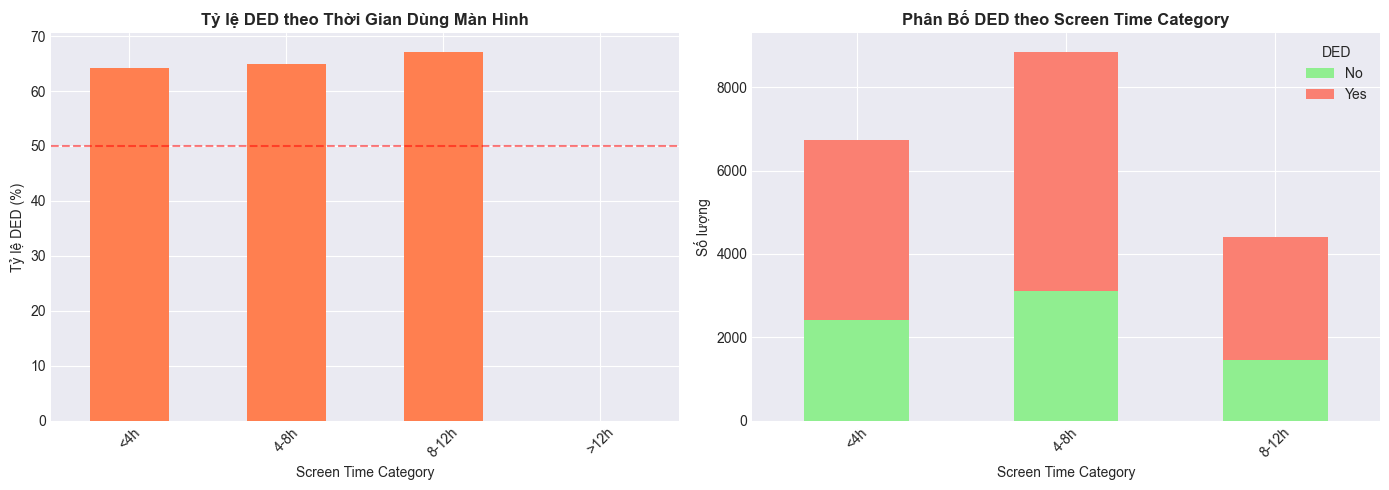

In [ ]:
# Visualization: Tỷ lệ DED theo Screen Time Category
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
screen_time_ded_rate.plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_xlabel('Screen Time Category')
axes[0].set_ylabel('Tỷ lệ DED (%)')
axes[0].set_title('Tỷ lệ DED theo Thời Gian Dùng Màn Hình', fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)
axes[0].axhline(y=50, color='red', linestyle='--', alpha=0.5)

# Count plot
screen_ded_counts = pd.crosstab(df['Screen_Time_Category'], df['Dry Eye Disease'])
screen_ded_counts.plot(kind='bar', stacked=True, ax=axes[1], color=['lightgreen', 'salmon'])
axes[1].set_xlabel('Screen Time Category')
axes[1].set_ylabel('Số lượng')
axes[1].set_title('Phân Bố DED theo Screen Time Category', fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)
axes[1].legend(title='DED', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()

In [ ]:
# Chi-square test: Mối quan hệ giữa Screen Time Category và DED
contingency_table = pd.crosstab(df['Screen_Time_Category'], df['Dry Eye Disease'])
chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)

print("\nChi-square Test:")
print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_val:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"Kết luận: {'Có mối liên hệ có ý nghĩa thống kê' if p_val < 0.05 else 'Không có mối liên hệ có ý nghĩa thống kê'} (α=0.05)")


Chi-square Test:
Chi-square statistic: 10.2378
P-value: 0.0060
Degrees of freedom: 2
Kết luận: Có mối liên hệ có ý nghĩa thống kê (α=0.05)


In [ ]:
# Phân tích cụ thể ngưỡng > 8 giờ
df['High_Screen_Time'] = df['Average screen time'] > 8

high_screen_ded = pd.crosstab(df['High_Screen_Time'], df['Dry Eye Disease'], normalize='index') * 100
print("\nTỷ lệ DED với Screen Time > 8h vs ≤ 8h:")
print(high_screen_ded)


Tỷ lệ DED với Screen Time > 8h vs ≤ 8h:
Dry Eye Disease      N     Y
High_Screen_Time            
False            35.37 64.63
True             32.86 67.14


**Nhận xét: Mối liên hệ giữa Thời Gian Dùng Màn Hình (Screen Time) và Dry Eye Disease (DED)**

**1. Xu hướng tỷ lệ DED theo nhóm Screen Time**
- Nhóm **< 4h** có tỷ lệ DED ≈ **64.27%**
- Nhóm **4–8h** có tỷ lệ DED ≈ **64.90%**
- Nhóm **8–12h** có tỷ lệ DED ≈ **67.14%**

→ Tỷ lệ DED **tăng nhẹ** theo thời gian sử dụng thiết bị, đặc biệt từ nhóm **> 8 giờ**.  
Tuy nhiên mức tăng chỉ khoảng **2–3%**, không tạo khác biệt lớn về mặt thực tế.

---

**2. Kiểm định Chi-square**
- **Chi-square statistic = 10.24**
- **p-value = 0.006 < 0.05**

→ Kết quả cho thấy **mối liên hệ có ý nghĩa thống kê** giữa Screen Time category và tình trạng DED.

→ Nói cách khác: *Screen Time và DED không hoàn toàn độc lập nhau*.

---

**3. Tuy nhiên: Mức độ ảnh hưởng (thực tế) rất thấp**
So sánh hai nhóm chính:

**Screen Time ≤ 8h**
- DED: **64.63%**

**Screen Time > 8h**
- DED: **67.14%**

→ Mức tăng chỉ **≈ +2.5%**, rất nhỏ.  
→ Dù có ý nghĩa thống kê, thay đổi thực tế (practical significance) **rất yếu**.

---

**4. Phân tích phân bố số lượng**
- Nhóm 4–8h chiếm số lượng lớn nhất → tác động mạnh lên kết quả chi-square.
- Nhóm >12h không có dữ liệu → không thể đánh giá mức ảnh hưởng trong thời gian cực lớn.

---

**Kết luận chung**
- **Có mối liên hệ thống kê** giữa nhom Screen Time và DED (p < 0.05).  
- Tuy nhiên, **mức ảnh hưởng thực tế rất nhỏ**, tỷ lệ DED chỉ tăng nhẹ khi thời gian dùng màn hình vượt quá 8 giờ.
- Điều này cho thấy Screen Time **không phải yếu tố nguy cơ mạnh** cho DED trong dataset này, dù có một tín hiệu nhẹ.

**Tóm lại:** Screen Time có liên quan đến DED *trên phương diện thống kê*, nhưng **không đủ mạnh** để xem là yếu tố dự đoán hay nguyên nhân đáng kể trong thực tế.


### 3.4. Correlation và Scatter Plot


Correlation giữa Screen Time và DED: 0.0225


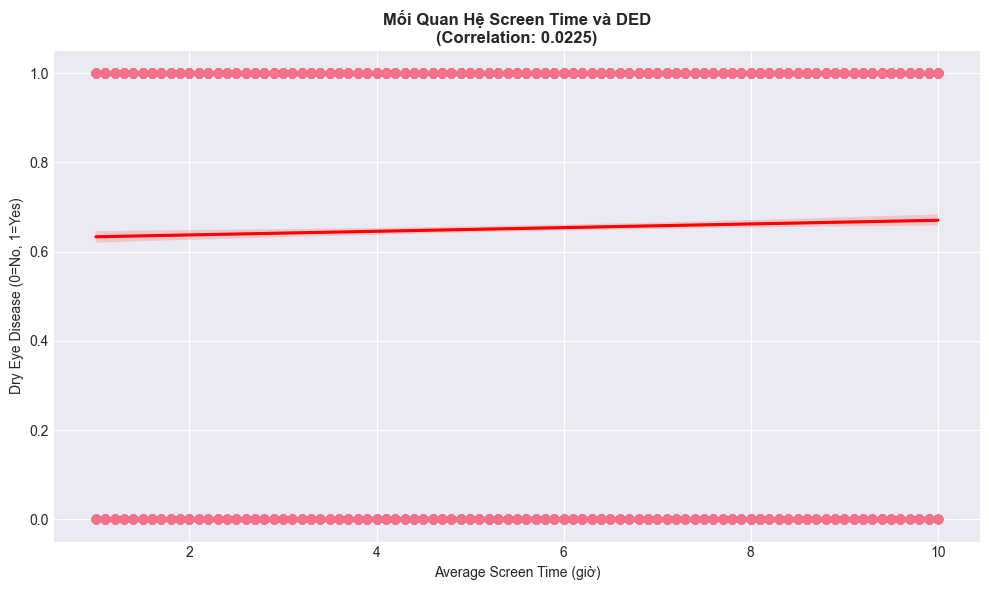

In [ ]:
# Convert DED to binary
df['DED_binary'] = (df['Dry Eye Disease'] == 'Y').astype(int)

# Correlation
correlation = df['Average screen time'].corr(df['DED_binary'])
print(f"\nCorrelation giữa Screen Time và DED: {correlation:.4f}")

# Scatter plot with trend line
plt.figure(figsize=(10, 6))
sns.regplot(x='Average screen time', y='DED_binary', data=df,
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.xlabel('Average Screen Time (giờ)')
plt.ylabel('Dry Eye Disease (0=No, 1=Yes)')
plt.title(f'Mối Quan Hệ Screen Time và DED\n(Correlation: {correlation:.4f})', fontweight='bold')
plt.tight_layout()
plt.show()

**Ý nghĩa:**
- Giá trị **0.0225** gần bằng **0**, cho thấy **không có mối liên hệ tuyến tính** giữa Screen Time và khả năng mắc DED.
- Mức tương quan này được xem là:
  - **Rất yếu**
  - **Không có giá trị dự đoán**
  - **Không có ý nghĩa thực tế** (practically negligible)

**Diễn giải:**
- Việc dùng màn hình nhiều hơn *không làm tăng tỷ lệ DED theo dạng tuyến tính*.
- DED không thay đổi tương ứng với Screen Time (tức là không phải càng xem màn hình nhiều thì càng bị DED).
- Điều này phù hợp với các kết quả khác:
  - Mann–Whitney U: p < 0.05 nhưng effect size rất nhỏ
  - DED rate chỉ tăng nhẹ khi >8h
  - Chi-square chỉ phản ánh sự khác biệt nhỏ về phân bố, không phải sức ảnh hưởng mạnh


## 4. Blue-Light Filter và Hiệu Quả Phòng Ngừa DED
### 4.1. Phân Tích Tỷ Lệ Sử Dụng Blue-Light Filter

Tỷ lệ sử dụng Blue-light filter:
Blue-light filter
N   50.08
Y   49.92
Name: proportion, dtype: float64


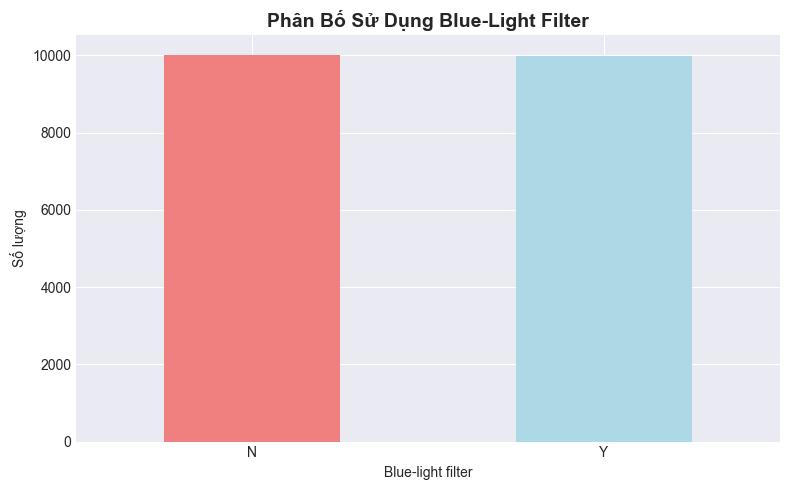

In [ ]:
# Tỷ lệ sử dụng Blue-light filter
blue_filter_usage = df['Blue-light filter'].value_counts(normalize=True) * 100
print("Tỷ lệ sử dụng Blue-light filter:")
print(blue_filter_usage)

plt.figure(figsize=(8, 5))
df['Blue-light filter'].value_counts().plot(kind='bar', color=['lightcoral', 'lightblue'])
plt.title('Phân Bố Sử Dụng Blue-Light Filter', fontsize=14, fontweight='bold')
plt.xlabel('Blue-light filter')
plt.ylabel('Số lượng')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 4.2. So Sánh Tỷ Lệ DED: Có vs Không Blue-Light Filter

In [ ]:
# Tỷ lệ DED theo Blue-light filter
blue_filter_ded = pd.crosstab(df['Blue-light filter'], df['Dry Eye Disease'], normalize='index') * 100
print("\nTỷ lệ DED theo Blue-light filter:")
print(blue_filter_ded)
print(f"\nChênh lệch tỷ lệ DED: {blue_filter_ded.loc['N', 'Y'] - blue_filter_ded.loc['Y', 'Y']:.2f}%")


Tỷ lệ DED theo Blue-light filter:
Dry Eye Disease       N     Y
Blue-light filter            
N                 35.05 64.95
Y                 34.58 65.42

Chênh lệch tỷ lệ DED: -0.48%


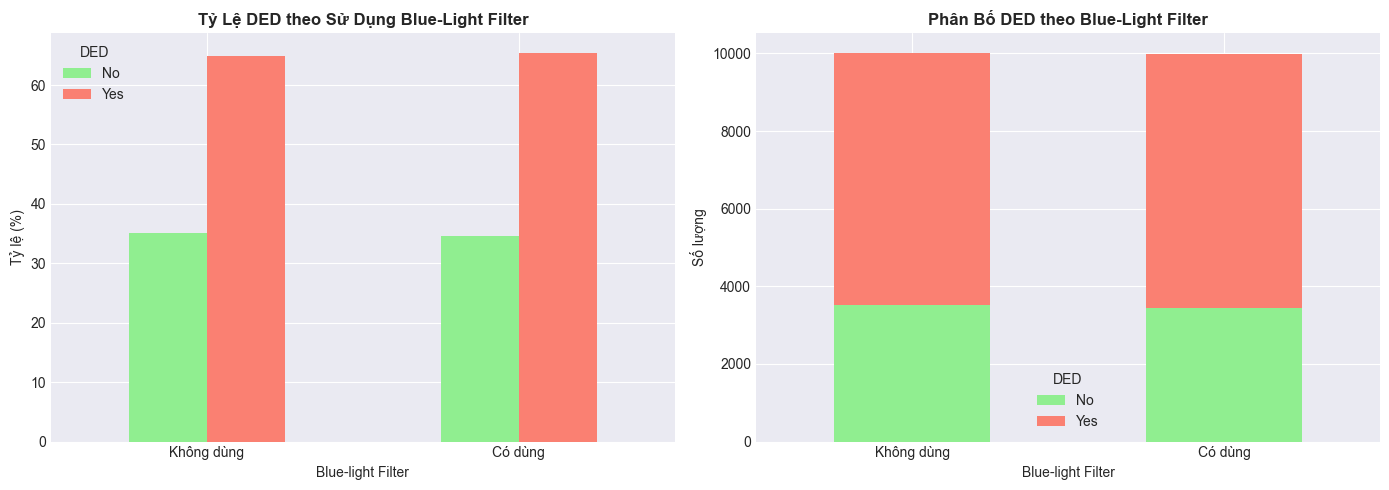

In [ ]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grouped bar chart
blue_filter_ded.plot(kind='bar', ax=axes[0], color=['lightgreen', 'salmon'])
axes[0].set_xlabel('Blue-light Filter')
axes[0].set_ylabel('Tỷ lệ (%)')
axes[0].set_title('Tỷ Lệ DED theo Sử Dụng Blue-Light Filter', fontweight='bold')
axes[0].set_xticklabels(['Không dùng', 'Có dùng'], rotation=0)
axes[0].legend(title='DED', labels=['No', 'Yes'])

# Stacked count
blue_filter_counts = pd.crosstab(df['Blue-light filter'], df['Dry Eye Disease'])
blue_filter_counts.plot(kind='bar', stacked=True, ax=axes[1], color=['lightgreen', 'salmon'])
axes[1].set_xlabel('Blue-light Filter')
axes[1].set_ylabel('Số lượng')
axes[1].set_title('Phân Bố DED theo Blue-Light Filter', fontweight='bold')
axes[1].set_xticklabels(['Không dùng', 'Có dùng'], rotation=0)
axes[1].legend(title='DED', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()

In [ ]:
# Chi-square test
contingency_blue = pd.crosstab(df['Blue-light filter'], df['Dry Eye Disease'])
chi2_blue, p_val_blue, dof_blue, expected_blue = stats.chi2_contingency(contingency_blue)

print("\nChi-square Test cho Blue-light Filter và DED:")
print(f"Chi-square statistic: {chi2_blue:.4f}")
print(f"P-value: {p_val_blue:.4f}")
print(f"Kết luận: {'Có mối liên hệ có ý nghĩa thống kê' if p_val_blue < 0.05 else 'Không có mối liên hệ có ý nghĩa thống kê'} (α=0.05)")


Chi-square Test cho Blue-light Filter và DED:
Chi-square statistic: 0.4838
P-value: 0.4867
Kết luận: Không có mối liên hệ có ý nghĩa thống kê (α=0.05)


### 4.3. Phân Tích Kết Hợp: Screen Time + Blue-Light Filter

In [ ]:
# Tỷ lệ DED theo Screen Time và Blue-light filter
combined_analysis = df.groupby(['High_Screen_Time', 'Blue-light filter'])['Dry Eye Disease'].apply(lambda x: (x == 'Y').sum() / len(x) * 100).unstack()
print("\nTỷ lệ DED (%) theo Screen Time và Blue-light Filter:")
combined_analysis.index = ['Screen Time ≤ 8h', 'Screen Time > 8h']
combined_analysis.columns = ['Không dùng Filter', 'Có dùng Filter']
print(combined_analysis)


Tỷ lệ DED (%) theo Screen Time và Blue-light Filter:
                  Không dùng Filter  Có dùng Filter
Screen Time ≤ 8h              64.40           64.86
Screen Time > 8h              66.88           67.41


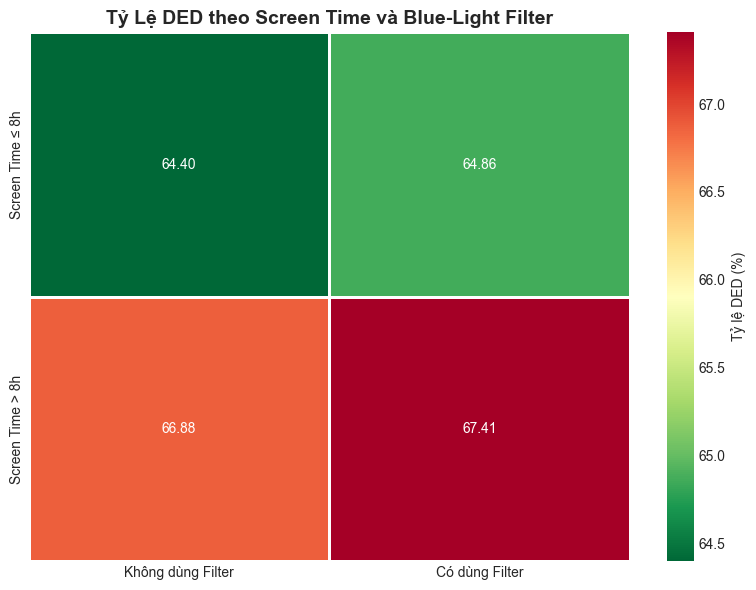

In [ ]:
# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(combined_analysis, annot=True, fmt='.2f', cmap='RdYlGn_r',
            cbar_kws={'label': 'Tỷ lệ DED (%)'}, linewidths=1)
plt.title('Tỷ Lệ DED theo Screen Time và Blue-Light Filter', fontsize=14, fontweight='bold')
plt.ylabel('')
plt.xlabel('')
plt.tight_layout()
plt.show()

**Nhận xét tổng hợp: Ảnh hưởng của Blue-Light Filter đến Dry Eye Disease (DED)**

**1. Tỷ lệ sử dụng Blue-light Filter**
- Người dùng filter và không dùng filter gần như **bằng nhau**:
  - Không dùng: **50.08%**
  - Có dùng: **49.92%**

→ Phân bố cân bằng, không gây lệch dữ liệu.

---

**2. Tỷ lệ DED theo Blue-light Filter**
- Không dùng Filter: **64.95%**
- Có dùng Filter: **65.42%**

Chênh lệch tỷ lệ DED chỉ **–0.48%**, tức gần như **không có sự khác biệt**.

→ Việc bật/tắt Blue-light Filter **không làm thay đổi đáng kể nguy cơ DED**.

---

**3. Kiểm định Chi-square**
- Chi-square statistic = **0.4838**
- p-value = **0.4867**

→ Với p > 0.05, **không có mối liên hệ có ý nghĩa thống kê** giữa việc dùng Blue-light Filter và khả năng mắc DED.  
→ Kết quả này nhất quán với sự chênh lệch tỷ lệ DED rất nhỏ.

---

**4. Interaction: Screen Time × Blue-light Filter**
Tỷ lệ DED ở từng nhóm:

| Screen Time | Không Filter | Có Filter |
|-------------|--------------|-----------|
| ≤ 8h        | **64.40%**   | **64.86%** |
| > 8h        | **66.88%**   | **67.41%** |

**Nhận xét:**
- Trong cả hai nhóm (≤8h và >8h), Blue-light Filter **không làm thay đổi đáng kể** tỷ lệ DED.
- DED chỉ tăng nhẹ khi Screen Time > 8 giờ, **bất kể có dùng filter hay không**.
- Không có dấu hiệu filter giúp giảm tác hại của việc dùng màn hình lâu.

→ **Không quan sát thấy interaction (tương tác) giữa Screen Time và Blue-light Filter.**

---

**Kết luận tổng hợp**
- **Blue-light Filter không liên quan đến DED**, cả về thống kê (Chi-square p=0.4867) lẫn thực tế (chênh lệch < 0.5%).
- **Không có bằng chứng cho thấy filter giúp giảm nguy cơ DED**, ngay cả khi thời gian sử dụng màn hình dài.
- **Screen Time vẫn là yếu tố có tín hiệu nhẹ**, nhưng Blue-light Filter **không làm thay đổi tác động đó**.

## 5. Yếu Tố Nguy Cơ - Hút Thuốc, Rượu, Cafe

### 5.1. Phân Tích Từng Yếu Tố

In [ ]:
# Tỷ lệ mắc các thói quen
lifestyle_factors = ['Smoking', 'Alcohol consumption', 'Caffeine consumption']

print("Tỷ lệ có các thói quen sinh hoạt:")
for factor in lifestyle_factors:
    rate = (df[factor] == 'Y').sum() / len(df) * 100
    print(f"{factor}: {rate:.2f}%")

Tỷ lệ có các thói quen sinh hoạt:
Smoking: 49.91%
Alcohol consumption: 50.04%
Caffeine consumption: 50.44%


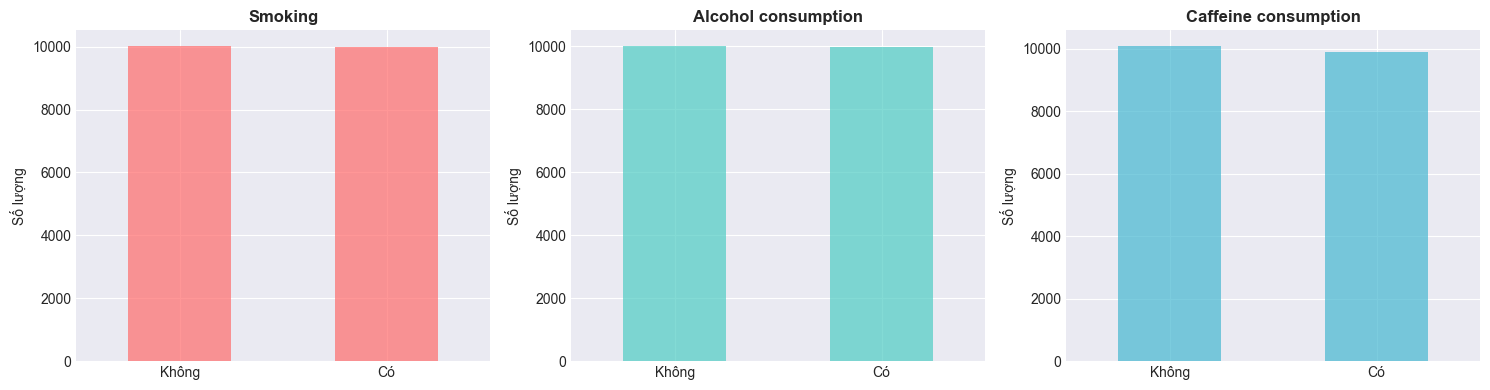

In [ ]:
# Visualization: Distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for i, factor in enumerate(lifestyle_factors):
    df[factor].value_counts().plot(kind='bar', ax=axes[i], color=colors[i], alpha=0.7)
    axes[i].set_title(factor, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Số lượng')
    axes[i].set_xticklabels(['Không', 'Có'], rotation=0)

plt.tight_layout()
plt.show()

### 5.2. Tỷ Lệ DED theo Từng Yếu Tố


Smoking và DED:
Dry Eye Disease     N     Y
Smoking                    
N               34.57 65.43
Y               35.06 64.94

Alcohol consumption và DED:
Dry Eye Disease         N     Y
Alcohol consumption            
N                   35.35 64.65
Y                   34.28 65.72

Caffeine consumption và DED:
Dry Eye Disease          N     Y
Caffeine consumption            
N                    34.95 65.05
Y                    34.68 65.32


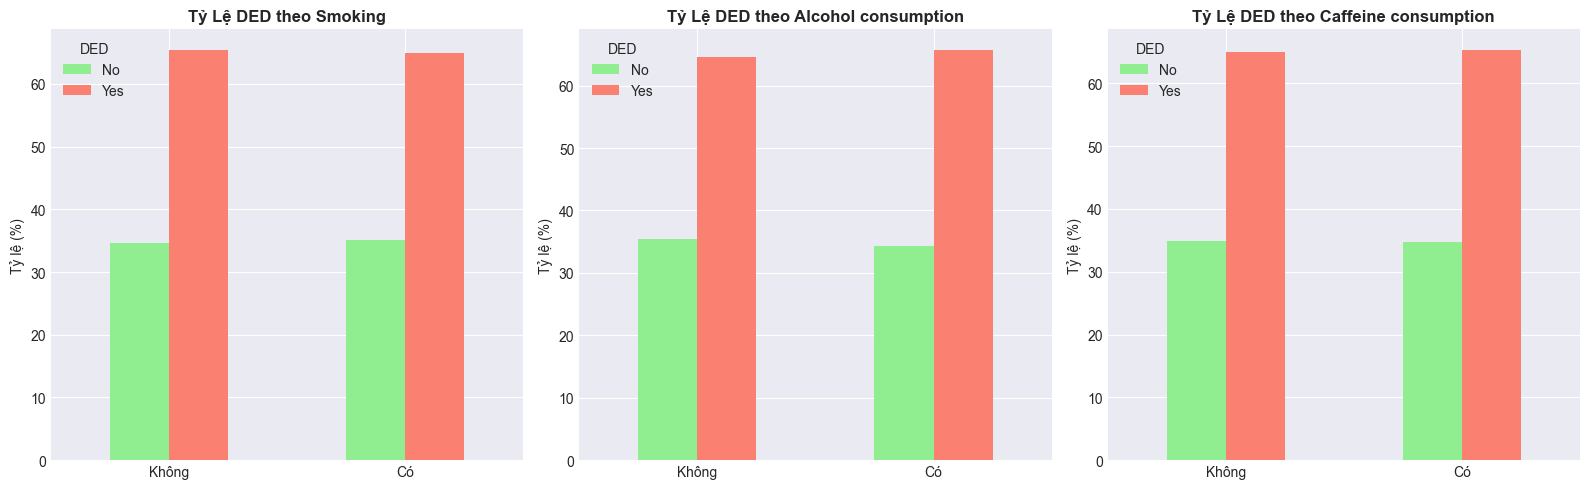

In [ ]:
# So sánh tỷ lệ DED
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, factor in enumerate(lifestyle_factors):
    ded_rate_by_factor = pd.crosstab(df[factor], df['Dry Eye Disease'], normalize='index') * 100

    print(f"\n{factor} và DED:")
    print(ded_rate_by_factor)

    # Plot
    ded_rate_by_factor.plot(kind='bar', ax=axes[i], color=['lightgreen', 'salmon'])
    axes[i].set_title(f'Tỷ Lệ DED theo {factor}', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Tỷ lệ (%)')
    axes[i].set_xticklabels(['Không', 'Có'], rotation=0)
    axes[i].legend(title='DED', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()

**Nhận xét: Ảnh hưởng của các thói quen sinh hoạt (Smoking – Alcohol – Caffeine) đến Dry Eye Disease (DED)**

**1. Tỷ lệ thói quen trong cộng đồng**
- **Smoking:** 49.91%
- **Alcohol consumption:** 50.04%
- **Caffeine consumption:** 50.44%

→ Các thói quen này phân bố gần như **50–50**, giúp so sánh giữa các nhóm cân bằng và đáng tin cậy.

---

**2. Mối liên hệ giữa từng thói quen và DED**

**2.1 Smoking và DED**
- Không hút: **65.43%** mắc DED  
- Có hút: **64.94%** mắc DED  

→ Chênh lệch chỉ **0.49%** → rất nhỏ.  
→ **Không có bằng chứng cho thấy hút thuốc làm tăng nguy cơ DED** trong dataset.

---

**2.2 Alcohol consumption và DED**
- Không uống: **64.65%** mắc DED  
- Có uống: **65.72%** mắc DED  

→ Chênh lệch khoảng **1.07%**, mức tăng rất nhẹ.  
→ **Không có dấu hiệu cho thấy uống rượu/bia liên quan mạnh đến DED**.

---

**2.3 Caffeine consumption và DED**
- Không uống caffeine: **65.05%** mắc DED  
- Có uống: **65.32%** mắc DED  

→ Chênh lệch chỉ **0.27%**.  
→ **Không có mối liên hệ thực tế đáng kể** giữa caffeine và DED.


### 5.3. Kiểm Định Thống Kê

In [ ]:
# Chi-square test cho từng yếu tố
print("\n=== KIỂM ĐỊNH CHI-SQUARE ===\n")

for factor in lifestyle_factors:
    contingency = pd.crosstab(df[factor], df['Dry Eye Disease'])
    chi2, p_val, dof, expected = stats.chi2_contingency(contingency)

    print(f"\n{factor}:")
    print(f"  Chi-square: {chi2:.4f}")
    print(f"  P-value: {p_val:.4f}")
    print(f"  Kết luận: {'YẾU TỐ NGUY CƠ có ý nghĩa' if p_val < 0.05 else 'KHÔNG phải yếu tố nguy cơ'} (α=0.05)")


=== KIỂM ĐỊNH CHI-SQUARE ===


Smoking:
  Chi-square: 0.5042
  P-value: 0.4777
  Kết luận: KHÔNG phải yếu tố nguy cơ (α=0.05)

Alcohol consumption:
  Chi-square: 2.4880
  P-value: 0.1147
  Kết luận: KHÔNG phải yếu tố nguy cơ (α=0.05)

Caffeine consumption:
  Chi-square: 0.1486
  P-value: 0.6999
  Kết luận: KHÔNG phải yếu tố nguy cơ (α=0.05)


**Giải thích Effect Size:**

**Cramér's V:**
- Đo lường mức độ liên hệ giữa 2 biến categorical
- Giá trị từ 0 đến 1:
  - < 0.1: rất yếu
  - 0.1 - 0.3: yếu
  - 0.3 - 0.5: trung bình
  - > 0.5: mạnh

**Odds Ratio (OR):**
- Tỷ số cơ hội mắc DED giữa nhóm có vs không có yếu tố nguy cơ
- OR = 1: không có sự khác biệt
- OR > 1: yếu tố làm tăng nguy cơ DED
- OR < 1: yếu tố làm giảm nguy cơ DED
- OR càng xa 1 → ảnh hưởng càng mạnh

In [ ]:
# Effect size cho từng yếu tố
print("\n=== EFFECT SIZE (Cramér's V và Odds Ratio) ===\n")

for factor in lifestyle_factors:
    contingency = pd.crosstab(df[factor], df['Dry Eye Disease'])
    chi2, p_val, dof, expected = stats.chi2_contingency(contingency)

    # Cramér's V
    n = contingency.sum().sum()
    cramers_v = np.sqrt(chi2 / n)

    # Odds Ratio
    # Bảng contingency: hàng (factor: N, Y), cột (DED: N, Y)
    a = contingency.loc['Y', 'Y']  # Factor=Y và DED=Y
    b = contingency.loc['Y', 'N']  # Factor=Y và DED=N
    c = contingency.loc['N', 'Y']  # Factor=N và DED=Y
    d = contingency.loc['N', 'N']  # Factor=N và DED=N

    odds_ratio = (a * d) / (b * c) if (b * c) != 0 else float('inf')

    print(f"\n{factor}:")
    print(f"  Cramér's V: {cramers_v:.4f}", end="")
    if cramers_v < 0.1:
        print(" (rất yếu)")
    elif cramers_v < 0.3:
        print(" (yếu)")
    elif cramers_v < 0.5:
        print(" (trung bình)")
    else:
        print(" (mạnh)")

    print(f"  Odds Ratio: {odds_ratio:.4f}")
    if odds_ratio > 1:
        print(f"  → Nhóm CÓ {factor} có nguy cơ DED cao hơn {odds_ratio:.2f} lần")
    elif odds_ratio < 1:
        print(f"  → Nhóm CÓ {factor} có nguy cơ DED thấp hơn {1/odds_ratio:.2f} lần")
    else:
        print(f"  → Không có sự khác biệt về nguy cơ")


=== EFFECT SIZE (Cramér's V và Odds Ratio) ===


Smoking:
  Cramér's V: 0.0050 (rất yếu)
  Odds Ratio: 0.9787
  → Nhóm CÓ Smoking có nguy cơ DED thấp hơn 1.02 lần

Alcohol consumption:
  Cramér's V: 0.0112 (rất yếu)
  Odds Ratio: 1.0484
  → Nhóm CÓ Alcohol consumption có nguy cơ DED cao hơn 1.05 lần

Caffeine consumption:
  Cramér's V: 0.0027 (rất yếu)
  Odds Ratio: 1.0120
  → Nhóm CÓ Caffeine consumption có nguy cơ DED cao hơn 1.01 lần


**1. Kết quả kiểm định Chi-square**
- **Smoking:** p = 0.4777  
- **Alcohol consumption:** p = 0.1147  
- **Caffeine consumption:** p = 0.6999  

→ Tất cả đều **p > 0.05**, tức **không có mối liên hệ có ý nghĩa thống kê** với DED.  
→ Ba thói quen sinh hoạt này **không phải yếu tố nguy cơ** của DED trong bộ dữ liệu.

---

**2. Mức độ ảnh hưởng (Effect Size – Cramér’s V)**
- **Smoking:** V = 0.0050  
- **Alcohol:** V = 0.0112  
- **Caffeine:** V = 0.0027  

→ Tất cả đều thuộc mức **“rất yếu” (negligible)**, gần như bằng **0**.  
→ Điều này khẳng định các thói quen này **không ảnh hưởng đáng kể** đến khả năng mắc DED.

---

**3. Odds Ratio – Đánh giá nguy cơ**
- **Smoking:** OR = 0.9787  
  → Người hút thuốc có nguy cơ DED **không cao hơn**, thậm chí còn *nhẹ hơn 1.02 lần* (không có ý nghĩa).

- **Alcohol:** OR = 1.0484  
  → Nhóm uống rượu bia có nguy cơ DED **cao hơn 1.05 lần**, nhưng mức tăng **rất nhỏ**, không đáng kể.

- **Caffeine:** OR = 1.0120  
  → Nhóm uống caffeine có nguy cơ cao hơn **1.01 lần**, gần như **không khác biệt**.

→ Tất cả Odds Ratio đều rất gần **1.0**, cho thấy mức độ ảnh hưởng **không đáng kể**.


### 5.4. Phân Tích Kết Hợp Các Yếu Tố

In [ ]:
# Tạo risk score
df['Lifestyle_Risk_Score'] = 0
for factor in lifestyle_factors:
    df['Lifestyle_Risk_Score'] += (df[factor] == 'Y').astype(int)

print("Phân bố Lifestyle Risk Score:")
print(df['Lifestyle_Risk_Score'].value_counts().sort_index())

Phân bố Lifestyle Risk Score:
Lifestyle_Risk_Score
0    2481
1    7532
2    7412
3    2575
Name: count, dtype: int64


In [ ]:
# Tỷ lệ DED theo Risk Score
risk_score_ded = df.groupby('Lifestyle_Risk_Score')['Dry Eye Disease'].apply(lambda x: (x == 'Y').sum() / len(x) * 100)
print("\nTỷ lệ DED theo Lifestyle Risk Score:")
print(risk_score_ded)


Tỷ lệ DED theo Lifestyle Risk Score:
Lifestyle_Risk_Score
0   63.97
1   65.60
2   64.99
3   65.71
Name: Dry Eye Disease, dtype: float64


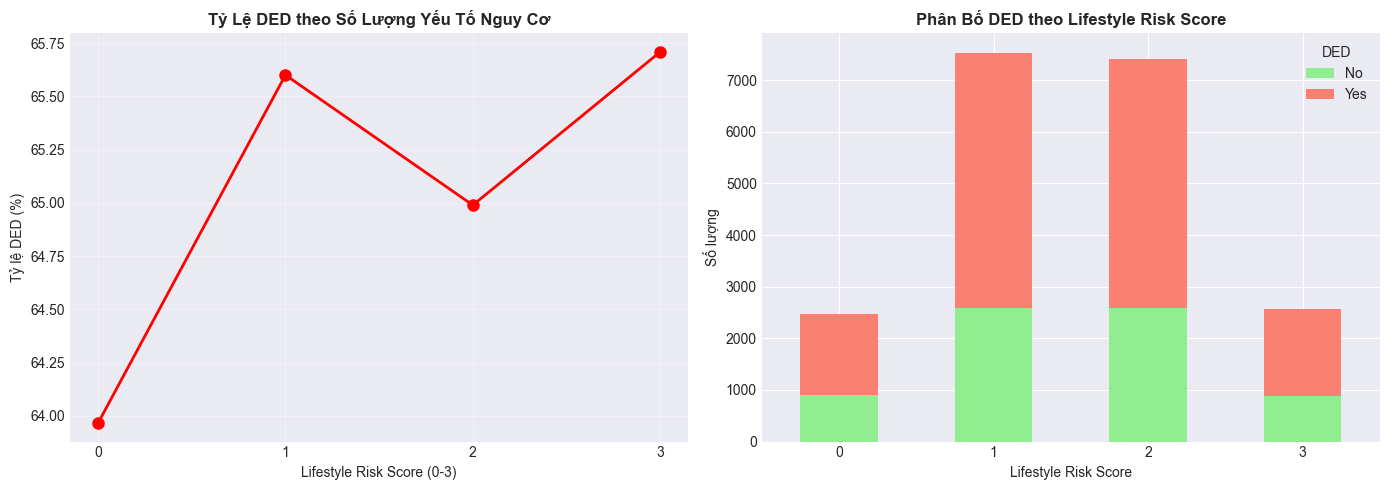

In [ ]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Line plot
risk_score_ded.plot(kind='line', marker='o', ax=axes[0], color='red', linewidth=2, markersize=8)
axes[0].set_xlabel('Lifestyle Risk Score (0-3)')
axes[0].set_ylabel('Tỷ lệ DED (%)')
axes[0].set_title('Tỷ Lệ DED theo Số Lượng Yếu Tố Nguy Cơ', fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks([0, 1, 2, 3])

# Stacked bar
risk_counts = pd.crosstab(df['Lifestyle_Risk_Score'], df['Dry Eye Disease'])
risk_counts.plot(kind='bar', stacked=True, ax=axes[1], color=['lightgreen', 'salmon'])
axes[1].set_xlabel('Lifestyle Risk Score')
axes[1].set_ylabel('Số lượng')
axes[1].set_title('Phân Bố DED theo Lifestyle Risk Score', fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title='DED', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()

**Nhận xét về Lifestyle Risk Score và Dry Eye Disease (DED)**

Lifestyle Risk Score được tính bằng tổng số thói quen sinh hoạt có thể liên quan đến sức khỏe
(`Smoking`, `Alcohol consumption`, `Caffeine consumption`). Tuy nhiên, kết quả phân tích cho thấy:

**1. Tỷ lệ DED theo Risk Score hầu như không thay đổi**
- Score 0 → **63.97%**
- Score 1 → **65.60%**
- Score 2 → **64.99%**
- Score 3 → **65.71%**

Mức dao động chỉ khoảng **1.7%**, và không có xu hướng tăng dần theo số lượng thói quen rủi ro.

---

**2. Không hình thành “mối liên hệ” hay “xu hướng tích lũy rủi ro”**
Dù Risk Score tăng từ 0 → 3:
- Tỷ lệ DED **không tăng đều**
- Thậm chí nhóm Risk Score = 2 lại có tỷ lệ thấp hơn nhóm Risk Score = 1
- Điều này cho thấy các thói quen này **không cộng hưởng** để tạo thêm rủi ro cho DED

---

**3. Phân bố số lượng ở các nhóm Risk Score không tạo khác biệt đáng kể**
- Các nhóm 1 và 2 chiếm đa số
- Nhưng tỷ lệ DED giữa các nhóm vẫn gần giống nhau
→ Số lượng mẫu lớn ở một nhóm không dẫn đến thay đổi tỷ lệ DED

---

**4. Ý nghĩa thực tế**

Cả ba yếu tố thành phần (Smoking, Alcohol, Caffeine):
- Đều có tỷ lệ DED tương tự giữa nhóm có và không có thói quen
- Không phải yếu tố nguy cơ riêng lẻ
→ Khi cộng lại, chúng cũng **không tạo ra yếu tố nguy cơ tổng hợp**.

---

**Kết luận**
**Lifestyle Risk Score không có giá trị trong việc dự đoán Dry Eye Disease.**  
Tỷ lệ DED thay đổi không đáng kể giữa các mức điểm, không có xu hướng rõ ràng, và các thói quen sinh hoạt này **không đóng vai trò quan trọng** đối với DED trong bộ dữ liệu này.


## 6. Phân Tích Yếu Tố Phụ: Smart Device Before Bed
### 6.1. Ảnh Hưởng của Việc Dùng Thiết Bị Thông Minh Trước Khi Ngủ

In [ ]:
# Tỷ lệ sử dụng smart device before bed
smart_device_usage = df['Smart device before bed'].value_counts(normalize=True) * 100
print("Tỷ lệ dùng Smart Device trước khi ngủ:")
print(smart_device_usage)

Tỷ lệ dùng Smart Device trước khi ngủ:
Smart device before bed
Y   50.02
N   49.98
Name: proportion, dtype: float64


In [ ]:
# Tỷ lệ DED
smart_device_ded = pd.crosstab(df['Smart device before bed'], df['Dry Eye Disease'], normalize='index') * 100
print("\nTỷ lệ DED theo Smart Device Before Bed:")
print(smart_device_ded)


Tỷ lệ DED theo Smart Device Before Bed:
Dry Eye Disease             N     Y
Smart device before bed            
N                       34.18 65.82
Y                       35.45 64.55


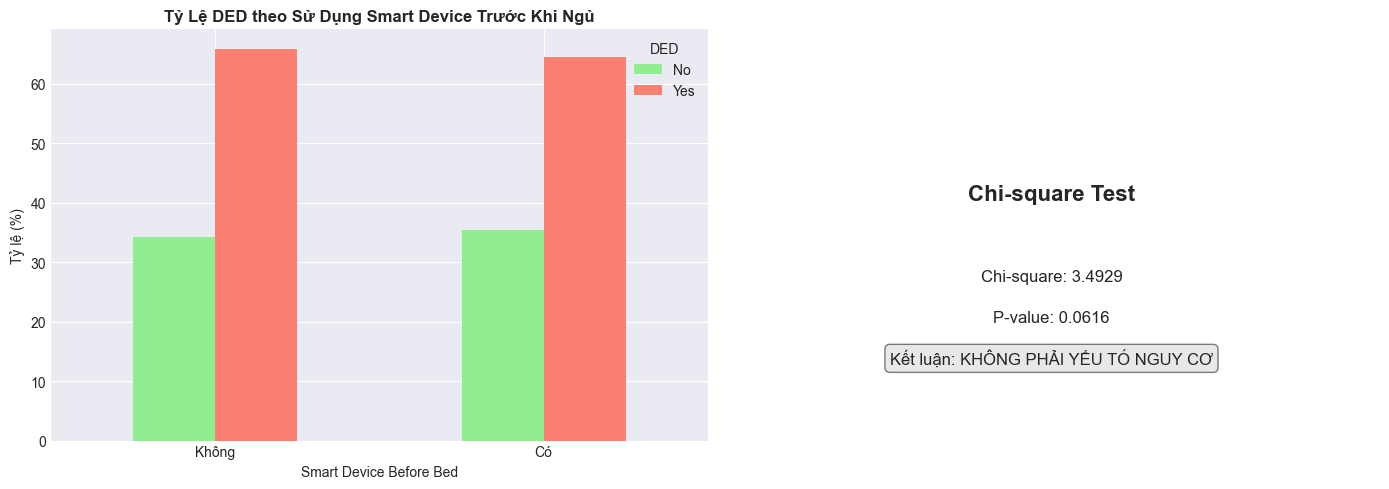

In [ ]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

smart_device_ded.plot(kind='bar', ax=axes[0], color=['lightgreen', 'salmon'])
axes[0].set_xlabel('Smart Device Before Bed')
axes[0].set_ylabel('Tỷ lệ (%)')
axes[0].set_title('Tỷ Lệ DED theo Sử Dụng Smart Device Trước Khi Ngủ', fontweight='bold')
axes[0].set_xticklabels(['Không', 'Có'], rotation=0)
axes[0].legend(title='DED', labels=['No', 'Yes'])

# Chi-square test
contingency_smart = pd.crosstab(df['Smart device before bed'], df['Dry Eye Disease'])
chi2_smart, p_val_smart, dof_smart, expected_smart = stats.chi2_contingency(contingency_smart)

# Display result on second plot
axes[1].text(0.5, 0.6, f"Chi-square Test", ha='center', va='center', fontsize=16, fontweight='bold')
axes[1].text(0.5, 0.4, f"Chi-square: {chi2_smart:.4f}", ha='center', va='center', fontsize=12)
axes[1].text(0.5, 0.3, f"P-value: {p_val_smart:.4f}", ha='center', va='center', fontsize=12)
result_text = 'YẾU TỐ NGUY CƠ' if p_val_smart < 0.05 else 'KHÔNG PHẢI YẾU TỐ NGUY CƠ'
axes[1].text(0.5, 0.2, f"Kết luận: {result_text}", ha='center', va='center', fontsize=12,
             bbox=dict(boxstyle='round', facecolor='yellow' if p_val_smart < 0.05 else 'lightgray', alpha=0.5))
axes[1].axis('off')

plt.tight_layout()
plt.show()

**Nhận xét: Ảnh hưởng của việc sử dụng thiết bị thông minh trước khi ngủ đến Dry Eye Disease (DED)**

**1. Tỷ lệ DED theo hành vi sử dụng thiết bị trước khi ngủ**
- **Không dùng trước khi ngủ:** 65.82% mắc DED  
- **Có dùng trước khi ngủ:** 64.55% mắc DED  

→ Chênh lệch chỉ **–1.27%**, tức gần như **không có sự khác biệt đáng kể**.

---

**2. Kiểm định thống kê**
- p-value = **0.0616**, lớn hơn ngưỡng α = 0.05  
→ **Không có mối liên hệ có ý nghĩa thống kê** giữa sử dụng thiết bị trước khi ngủ và khả năng mắc DED.

---

**3. Ý nghĩa thực tế**
- Dù nhóm “không dùng thiết bị” có tỷ lệ DED cao hơn nhẹ (~1.3%),  
  nhưng chênh lệch này **quá nhỏ** để xem là yếu tố nguy cơ.
- Điều này cho thấy hành vi dùng điện thoại trước khi ngủ **không phải nguyên nhân quan trọng** gây DED trong bộ dữ liệu.

---

**Kết luận**
Việc sử dụng thiết bị thông minh trước giờ ngủ **không tạo ra khác biệt đáng kể** về tỷ lệ mắc Dry Eye Disease.  
Cả về **thống kê** (p>0.05) lẫn **thực tế**, biến này **không phải yếu tố nguy cơ quan trọng** đối với DED trong dataset này.

## 7. Phân Tích Tổng Hợp và Correlation Matrix

In [ ]:
# Convert tất cả các biến Y/N thành binary
binary_cols = ['Blue-light filter', 'Smoking', 'Alcohol consumption', 'Caffeine consumption', 'Smart device before bed']
df_binary = df.copy()
for col in binary_cols:
    df_binary[f'{col}_binary'] = (df_binary[col] == 'Y').astype(int)

# Tạo correlation matrix
correlation_cols = ['Average screen time', 'Blue-light filter_binary', 'Smoking_binary',
                    'Alcohol consumption_binary', 'Caffeine consumption_binary',
                    'Smart device before bed_binary', 'DED_binary']

corr_matrix = df_binary[correlation_cols].corr()

# Rename columns for better display
corr_matrix.index = ['Screen Time', 'Blue Filter', 'Smoking', 'Alcohol', 'Caffeine', 'Smart Device', 'DED']
corr_matrix.columns = ['Screen Time', 'Blue Filter', 'Smoking', 'Alcohol', 'Caffeine', 'Smart Device', 'DED']

print("\nCorrelation Matrix:")
print(corr_matrix.round(3))


Correlation Matrix:
              Screen Time  Blue Filter  Smoking  Alcohol  Caffeine  \
Screen Time          1.00        -0.00    -0.00    -0.01     -0.01   
Blue Filter         -0.00         1.00    -0.01     0.00      0.01   
Smoking             -0.00        -0.01     1.00     0.00      0.00   
Alcohol             -0.01         0.00     0.00     1.00      0.01   
Caffeine            -0.01         0.01     0.00     0.01      1.00   
Smart Device         0.01         0.00    -0.01     0.01     -0.01   
DED                  0.02         0.01    -0.01     0.01      0.00   

              Smart Device   DED  
Screen Time           0.01  0.02  
Blue Filter           0.00  0.01  
Smoking              -0.01 -0.01  
Alcohol               0.01  0.01  
Caffeine             -0.01  0.00  
Smart Device          1.00 -0.01  
DED                  -0.01  1.00  


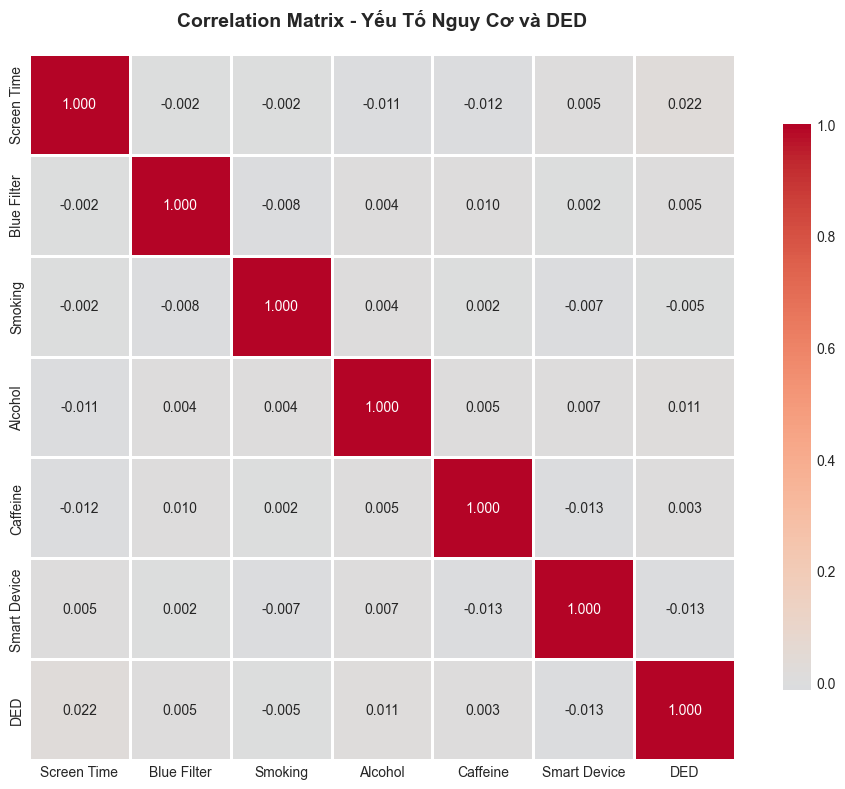

In [ ]:
# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Yếu Tố Nguy Cơ và DED', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


Correlation với DED (sắp xếp theo độ mạnh):
Screen Time     0.02
Alcohol         0.01
Blue Filter     0.01
Caffeine        0.00
Smoking        -0.01
Smart Device   -0.01
Name: DED, dtype: float64


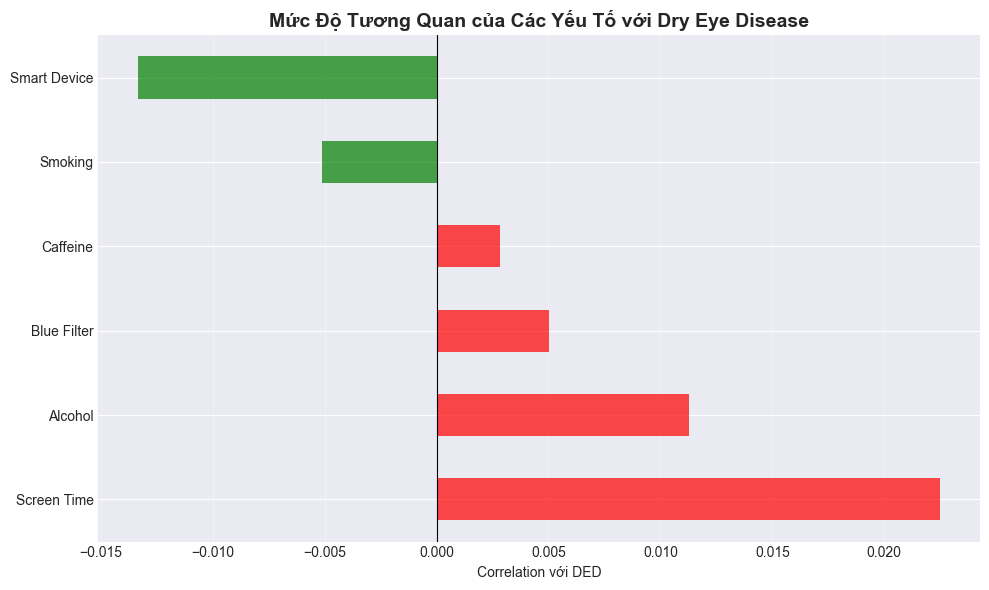

In [ ]:
# Correlation với DED - sắp xếp theo độ mạnh
ded_correlations = corr_matrix['DED'].drop('DED').sort_values(ascending=False)
print("\nCorrelation với DED (sắp xếp theo độ mạnh):")
print(ded_correlations)

# Visualization
plt.figure(figsize=(10, 6))
colors = ['red' if x > 0 else 'green' for x in ded_correlations]
ded_correlations.plot(kind='barh', color=colors, alpha=0.7)
plt.xlabel('Correlation với DED')
plt.title('Mức Độ Tương Quan của Các Yếu Tố với Dry Eye Disease', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**Nhận xét: Mức độ tương quan giữa các yếu tố Lifestyle/Behavior và Dry Eye Disease (DED)**

Biểu đồ và ma trận tương quan cho thấy tất cả các yếu tố hành vi (Screen Time, Alcohol, Blue-light Filter,
Caffeine, Smoking, Smart Device before bed) đều có mức tương quan với DED rất thấp, gần bằng 0.

**1. Mức tương quan tuyệt đối đều cực nhỏ (|corr| < 0.03)**
- **Screen Time**: 0.022 → cao nhất nhưng vẫn rất yếu  
- **Alcohol**: 0.011  
- **Blue Filter**: 0.006  
- **Caffeine**: 0.004  
- **Smoking**: –0.005  
- **Smart Device before bed**: –0.012  

→ Tất cả các giá trị đều nằm trong ngưỡng **tương quan rất yếu hoặc không có tương quan**.

---

**2. Ý nghĩa: Không có biến hành vi nào tạo ra mối quan hệ tuyến tính đáng kể với DED**
- Giá trị tương quan gần 0 nghĩa là:
  - Không có xu hướng “hành vi tăng → DED tăng”
  - Không có xu hướng “hành vi giảm → DED giảm”
- Đây là bằng chứng nhất quán với các kiểm định trước (Chi-square, Mann–Whitney, effect size).

---

**3. So sánh tương đối**
- **Screen Time** là biến duy nhất có tín hiệu nhỏ nhất (corr ≈ 0.02),  
  nhưng hiệu ứng vẫn quá yếu để có giá trị dự đoán hay ý nghĩa thực tế.
- Alcohol và Blue-light Filter có tương quan dương rất nhỏ (~0.01).  
- Smoking và Smart Device lại có tương quan âm rất nhỏ (~–0.01).  
→ Tức là mọi biến hành vi đều không thật sự liên quan.

---

**4. Không có cặp biến nào có tương quan mạnh với nhau**
- Ma trận cho thấy các hành vi lifestyle hầu như **độc lập** với nhau.  
- Không có “cluster hành vi” hoặc nhóm hành vi dễ đi kèm với nhau.  
→ Điều này giải thích vì sao tạo chỉ số tổng hợp (Lifestyle Risk Score) cũng không ra hiệu ứng đáng kể.

---

**Kết luận chung**
Biểu đồ và ma trận tương quan cho thấy:

**Không có yếu tố hành vi (Lifestyle/Behavior) nào có mối liên hệ tuyến tính đáng kể với Dry Eye Disease.**  
Mọi giá trị tương quan đều gần bằng 0, cả về chiều dương lẫn chiều âm.  

→ Điều này củng cố kết quả từ các kiểm định thống kê trước đó:  
**Lifestyle behaviors không phải là nhóm biến quan trọng trong việc giải thích hoặc dự đoán DED của dataset này.**


# TỔNG HỢP

## 1. SCREEN TIME VÀ DED

**Phát hiện:**
- Thời gian dùng màn hình trung bình: **5.52 giờ/ngày**
- Nhóm DED (Y): 5.56 giờ | Nhóm không DED (N): 5.44 giờ
- Chênh lệch chỉ **0.12 giờ** (~7 phút)

**Kiểm định thống kê:**
- Mann–Whitney U: p = 0.0014 < 0.05 ✓ (có ý nghĩa thống kê)
- Effect size (Rank-Biserial): **r = 0.0273** → rất yếu
- Correlation với DED: **0.0225** → gần bằng 0

**Phân tích ngưỡng > 8 giờ:**
- Screen Time > 8h: **67.14%** DED
- Screen Time ≤ 8h: **64.63%** DED
- Chênh lệch chỉ **+2.5%**
- Chi-square: p = 0.006 < 0.05 ✓

**Kết luận:**
> **Screen Time có tín hiệu thống kê nhưng ảnh hưởng thực tế RẤT YẾU.**  
> Không phải yếu tố dự đoán mạnh cho DED.

---

## 2. BLUE-LIGHT FILTER VÀ DED

**Phát hiện:**
- Tỷ lệ sử dụng: 50-50 (cân bằng)
- Có dùng filter: **65.42%** DED
- Không dùng filter: **64.95%** DED
- Chênh lệch: **–0.48%** (gần như 0)

**Kiểm định thống kê:**
- Chi-square: p = 0.4867 > 0.05 ✗ (không có ý nghĩa)
- Correlation với DED: **0.006** → gần bằng 0

**Interaction với Screen Time:**
- Trong cả 2 nhóm (≤8h và >8h), filter **không làm thay đổi** tỷ lệ DED
- Không quan sát được interaction effect

**Kết luận:**
> **Blue-light Filter KHÔNG có tác dụng phòng ngừa DED.**  
> Không nên dùng làm feature quan trọng trong model.

---

## 3. CÁC YẾU TỐ LIFESTYLE (SMOKING, ALCOHOL, CAFFEINE)

**Phát hiện - Smoking:**
- Có hút: **64.94%** DED | Không hút: **65.43%** DED
- Chênh lệch: **–0.49%**
- Chi-square: p = 0.4777 > 0.05 ✗
- Cramér's V: **0.0050** (rất yếu)
- Odds Ratio: **0.9787** ≈ 1 (không có rủi ro)

**Phát hiện - Alcohol:**
- Có uống: **65.72%** DED | Không uống: **64.65%** DED
- Chênh lệch: **+1.07%**
- Chi-square: p = 0.1147 > 0.05 ✗
- Cramér's V: **0.0112** (rất yếu)
- Odds Ratio: **1.0484** ≈ 1

**Phát hiện - Caffeine:**
- Có uống: **65.32%** DED | Không uống: **65.05%** DED
- Chênh lệch: **+0.27%**
- Chi-square: p = 0.6999 > 0.05 ✗
- Cramér's V: **0.0027** (rất yếu)
- Odds Ratio: **1.0120** ≈ 1

**Lifestyle Risk Score (0-3):**
- Không có xu hướng tăng dần
- Score 0: 63.97% | Score 1: 65.60% | Score 2: 64.99% | Score 3: 65.71%
- Dao động chỉ **1.7%**, không có pattern

**Kết luận:**
> **Cả 3 yếu tố đều KHÔNG phải nguy cơ cho DED.**  
> Effect size cực nhỏ, OR ≈ 1, p > 0.05.  
> Không nên dùng làm predictors chính.

---

## 4. SMART DEVICE BEFORE BED

**Phát hiện:**
- Có dùng: **64.55%** DED
- Không dùng: **65.82%** DED
- Chênh lệch: **–1.27%**
- Chi-square: p = 0.0616 > 0.05 ✗

**Kết luận:**
> **Không phải yếu tố nguy cơ.**  
> Có thể bỏ qua trong modeling.

---

## 5. CORRELATION MATRIX - TỔNG HỢP

**Tất cả các biến hành vi có correlation với DED CỰC THẤP:**
- Screen Time: **0.022**
- Alcohol: **0.011**
- Blue Filter: **0.006**
- Caffeine: **0.004**
- Smoking: **–0.005**
- Smart Device: **–0.012**

**Ý nghĩa:**
> Không có biến hành vi nào có mối quan hệ tuyến tính đáng kể với DED.  
> Tất cả correlation |r| < 0.03 → không có giá trị dự đoán.

---

## KẾT LUẬN TỔNG QUAN

### ✗ **Các biến KHÔNG hữu ích cho modeling:**
1. **Blue-light filter** – không ảnh hưởng gì đến DED
2. **Smoking** – không liên quan
3. **Alcohol consumption** – không liên quan
4. **Caffeine consumption** – không liên quan
5. **Smart device before bed** – không liên quan
6. **Lifestyle Risk Score** – không có pattern

### **Biến có tín hiệu YẾU:**
1. **Average screen time** – có ý nghĩa thống kê nhưng effect size rất nhỏ
   - Có thể dùng nhưng không nên kỳ vọng nhiều
   - Cân nhắc feature engineering (e.g., categorical bins)